In [2]:
# ============================================================
# Phase 3: Exploratory Analysis
# Goal: Understand WHY customers churn through visualizations
# ============================================================

# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This makes all our charts look clean and professional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# --- Load the master table we built in Phase 2 ---
df = pd.read_csv(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\master_customer_table.csv",
                 parse_dates=["first_purchase_date", "last_purchase_date"])

# --- Quick sanity check ---
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nChurn value counts:\n", df["churned"].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (93350, 13)

Column names:
 ['customer_unique_id', 'total_orders', 'total_spend', 'avg_spend_per_order', 'avg_review_score', 'avg_delivery_delay', 'first_purchase_date', 'last_purchase_date', 'customer_state', 'fav_category', 'days_since_last_purchase', 'customer_lifespan_days', 'churned']

Churn value counts:
 churned
1    55004
0    38346
Name: count, dtype: int64

First 3 rows:


,customer_unique_id,total_orders,total_spend,avg_spend_per_order,avg_review_score,avg_delivery_delay,first_purchase_date,last_purchase_date,customer_state,fav_category,days_since_last_purchase,customer_lifespan_days,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.9,129.9,5.0,-5.0,2018-05-10 10:56:27,2018-05-10 10:56:27,SP,cama_mesa_banho,111,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.9,18.9,4.0,-5.0,2018-05-07 11:11:27,2018-05-07 11:11:27,SP,beleza_saude,114,0,0
2,0000f46a3911fa3c0805444483337064,1,69.0,69.0,3.0,-2.0,2017-03-10 21:05:03,2017-03-10 21:05:03,SC,papelaria,536,0,1


In [3]:
# ============================================================
# Chart 1: Churn Rate by Average Review Score
# Business Question: Do unhappy customers churn more?
# ============================================================

# --- Step 1: Group customers by their rounded review score ---
# Each customer has an avg_review_score (e.g. 3.5, 4.0)
# We round to nearest 0.5 so we get clean buckets: 1, 1.5, 2 ... 5
df["review_bucket"] = (df["avg_review_score"] * 2).round() / 2

# --- Step 2: Calculate churn RATE per bucket ---
# For each review bucket: what % of customers in that group churned?
churn_by_review = (
    df.groupby("review_bucket")["churned"]
    .mean()          # mean of 0s and 1s = proportion that churned
    .mul(100)        # convert 0.58 → 58.0 (percentage)
    .reset_index()   # turn the index back into a regular column
    .rename(columns={"churned": "churn_rate"})
)

print(churn_by_review)

   review_bucket  churn_rate
0            1.0   60.293953
1            1.5   41.666667
2            2.0   62.034739
3            2.5   58.252427
4            3.0   62.142486
5            3.5   58.378378
6            4.0   59.858265
7            4.5   50.420168
8            5.0   57.740271


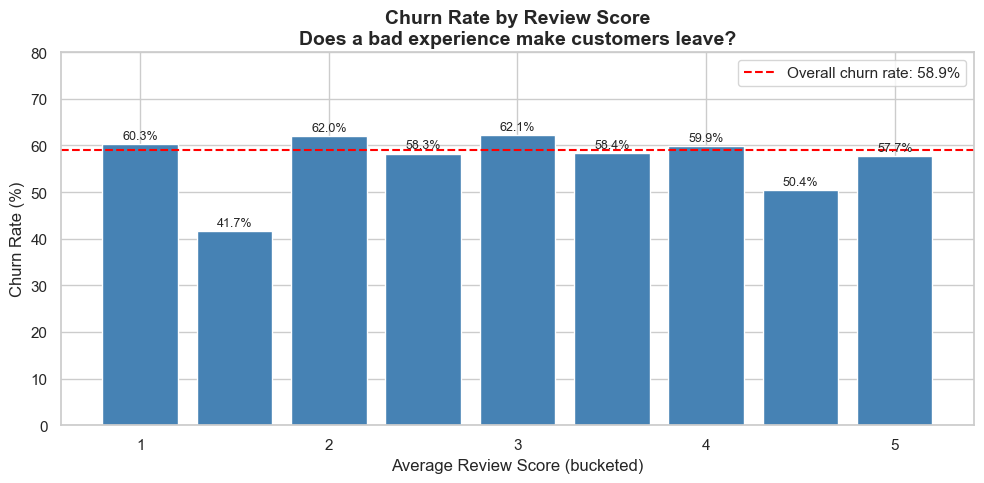

Chart 1 saved!


In [5]:
# --- Step 3: Plot the chart ---

fig, ax = plt.subplots()

# Bar chart: x = review score bucket, y = churn rate %
bars = ax.bar(
    churn_by_review["review_bucket"],  # x-axis: review scores
    churn_by_review["churn_rate"],     # y-axis: churn % 
    color="steelblue",
    width=0.4,                         # width of each bar
    edgecolor="white"
)

# --- Add the % number on top of each bar ---
# So we don't have to eyeball the height
for bar in bars:
    height = bar.get_height()   # get how tall this bar is
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position: center of bar
        height + 0.5,                        # y position: just above bar
        f"{height:.1f}%",                    # text: e.g. "60.3%"
        ha="center", va="bottom",            # alignment
        fontsize=9
    )

# --- Draw a horizontal reference line at overall churn rate ---
# This is our baseline — helps us see which buckets are above/below average
overall_churn = df["churned"].mean() * 100
ax.axhline(overall_churn, color="red", linestyle="--", linewidth=1.5,
           label=f"Overall churn rate: {overall_churn:.1f}%")

# --- Labels and formatting ---
ax.set_xlabel("Average Review Score (bucketed)")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Review Score\nDoes a bad experience make customers leave?")
ax.set_ylim(0, 80)   # y-axis from 0 to 80% so bars aren't cramped at top
ax.legend()

plt.tight_layout()   # prevents labels from getting cut off
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart1_churn_by_review.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved!")

In [7]:
# ============================================================
# Chart 2: Churn Rate by Delivery Delay
# Business Question: Do late deliveries drive churn?
# ============================================================

# --- Step 1: Understand the delivery delay column first ---
print("Delivery delay stats:")
print(df["avg_delivery_delay"].describe())

print("\nNegative values (early deliveries):", (df["avg_delivery_delay"] < 0).sum())
print("Zero delay")

Delivery delay stats:
count    93350.000000
mean       -11.847911
std         10.139417
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: avg_delivery_delay, dtype: float64

Negative values (early deliveries): 85805
Zero delay


In [9]:
# --- Step 2: Create meaningful delay buckets ---
# Instead of plotting every single delay value (-147 to +188),
# we group them into categories that tell a clear story

def delay_bucket(days):
    if days < -14:
        return "Very Early (>14 days early)"
    elif days < 0:
        return "Early (1-14 days early)"
    elif days == 0:
        return "On Time"
    elif days <= 7:
        return "Slightly Late (1-7 days)"
    elif days <= 21:
        return "Late (8-21 days)"
    else:
        return "Very Late (>21 days)"

# Apply this function to every row in the dataframe
df["delay_bucket"] = df["avg_delivery_delay"].apply(delay_bucket)

# --- Step 3: Calculate churn rate per bucket ---
# We also track customer count so we know which buckets are statistically meaningful
churn_by_delay = (
    df.groupby("delay_bucket")
    .agg(
        churn_rate=("churned", "mean"),      # proportion who churned
        customer_count=("churned", "count")  # how many customers in this bucket
    )
    .reset_index()
)

churn_by_delay["churn_rate"] = churn_by_delay["churn_rate"] * 100

# Sort in a logical order (early → late)
bucket_order = [
    "Very Early (>14 days early)",
    "Early (1-14 days early)",
    "On Time",
    "Slightly Late (1-7 days)",
    "Late (8-21 days)",
    "Very Late (>21 days)"
]
churn_by_delay["delay_bucket"] = pd.Categorical(
    churn_by_delay["delay_bucket"], 
    categories=bucket_order, 
    ordered=True
)
churn_by_delay = churn_by_delay.sort_values("delay_bucket")

print(churn_by_delay.to_string(index=False))

               delay_bucket  churn_rate  customer_count
Very Early (>14 days early)   61.010777           33776
    Early (1-14 days early)   57.959984           52029
                    On Time   46.839546            1234
   Slightly Late (1-7 days)   54.943820            3560
           Late (8-21 days)   59.150169            2071
       Very Late (>21 days)   70.882353             680


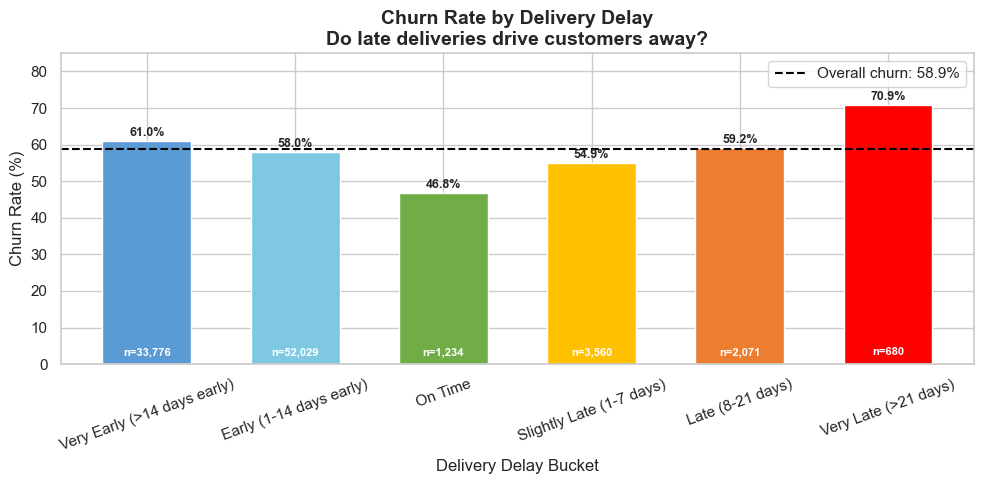

Chart 2 saved!


In [10]:
# --- Step 4: Plot the chart ---

fig, ax1 = plt.subplots()

# --- Color bars: red for late, green for on-time, blue for early ---
colors = [
    "#5b9bd5",   # Very Early - blue
    "#7ec8e3",   # Early - light blue
    "#70ad47",   # On Time - green (best!)
    "#ffc000",   # Slightly Late - amber
    "#ed7d31",   # Late - orange
    "#ff0000",   # Very Late - red (worst!)
]

bars = ax1.bar(
    churn_by_delay["delay_bucket"],
    churn_by_delay["churn_rate"],
    color=colors,
    edgecolor="white",
    width=0.6
)

# --- Add % labels on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

# --- Add customer count labels at the bottom of each bar ---
# So the reader knows how many customers back each number
for bar, count in zip(bars, churn_by_delay["customer_count"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        2,                              # 2% from the bottom
        f"n={count:,}",                 # e.g. "n=33,776"
        ha="center", va="bottom",
        fontsize=8, color="white",
        fontweight="bold"
    )

# --- Reference line ---
overall_churn = df["churned"].mean() * 100
ax1.axhline(overall_churn, color="black", linestyle="--", linewidth=1.5,
            label=f"Overall churn: {overall_churn:.1f}%")

# --- Formatting ---
ax1.set_xlabel("Delivery Delay Bucket")
ax1.set_ylabel("Churn Rate (%)")
ax1.set_title("Churn Rate by Delivery Delay\nDo late deliveries drive customers away?")
ax1.set_ylim(0, 85)
ax1.tick_params(axis="x", rotation=20)   # rotate x labels so they don't overlap
ax1.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart2_churn_by_delay.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 2 saved!")

In [11]:
# ============================================================
# Chart 3: Churn Rate by Product Category
# Business Question: Which categories retain customers best?
# ============================================================

# --- Step 1: See what categories exist and how common they are ---
category_counts = df["fav_category"].value_counts()

print(f"Total unique categories: {category_counts.nunique()}")
print("\nTop 20 categories by customer count:")
print(category_counts.head(20))

Total unique categories: 73

Top 20 categories by customer count:
fav_category
cama_mesa_banho                8870
beleza_saude                   8446
esporte_lazer                  7204
informatica_acessorios         6287
moveis_decoracao               5862
utilidades_domesticas          5393
relogios_presentes             5271
telefonia                      3939
automotivo                     3744
brinquedos                     3709
cool_stuff                     3451
ferramentas_jardim             3330
perfumaria                     2952
bebes                          2756
eletronicos                    2471
papelaria                      2176
fashion_bolsas_e_acessorios    1701
pet_shop                       1607
unknown                        1285
moveis_escritorio              1212
Name: count, dtype: int64


In [12]:
# --- Step 2: Translation dictionary ---
translation = {
    "cama_mesa_banho": "Bed & Bath",
    "beleza_saude": "Beauty & Health",
    "esporte_lazer": "Sports & Leisure",
    "informatica_acessorios": "Computers & Accessories",
    "moveis_decoracao": "Furniture & Decor",
    "utilidades_domesticas": "Home Appliances",
    "relogios_presentes": "Watches & Gifts",
    "telefonia": "Phones",
    "automotivo": "Automotive",
    "brinquedos": "Toys",
    "cool_stuff": "Cool Stuff",
    "ferramentas_jardim": "Tools & Garden",
    "perfumaria": "Perfumes",
    "bebes": "Baby Products",
    "eletronicos": "Electronics"
}

# --- Step 3: Filter to top 15 categories only ---
top15_cats = category_counts.head(15).index.tolist()
df_top15 = df[df["fav_category"].isin(top15_cats)].copy()

# --- Step 4: Apply translation ---
df_top15["category_en"] = df_top15["fav_category"].map(translation)

# --- Step 5: Calculate churn rate per category ---
churn_by_cat = (
    df_top15.groupby("category_en")
    .agg(
        churn_rate=("churned", "mean"),
        customer_count=("churned", "count")
    )
    .reset_index()
)
churn_by_cat["churn_rate"] = churn_by_cat["churn_rate"] * 100

# Sort from highest churn to lowest — tells a clearer story
churn_by_cat = churn_by_cat.sort_values("churn_rate", ascending=True)

print(churn_by_cat.to_string(index=False))

            category_en  churn_rate  customer_count
        Watches & Gifts   48.833238            5271
             Automotive   50.400641            3744
        Beauty & Health   51.491830            8446
        Home Appliances   52.401261            5393
          Baby Products   55.007257            2756
            Electronics   56.373938            2471
Computers & Accessories   59.615079            6287
             Bed & Bath   60.766629            8870
       Sports & Leisure   62.062743            7204
      Furniture & Decor   62.214261            5862
                 Phones   64.661081            3939
               Perfumes   65.684282            2952
         Tools & Garden   68.498498            3330
                   Toys   70.719871            3709
             Cool Stuff   73.833671            3451


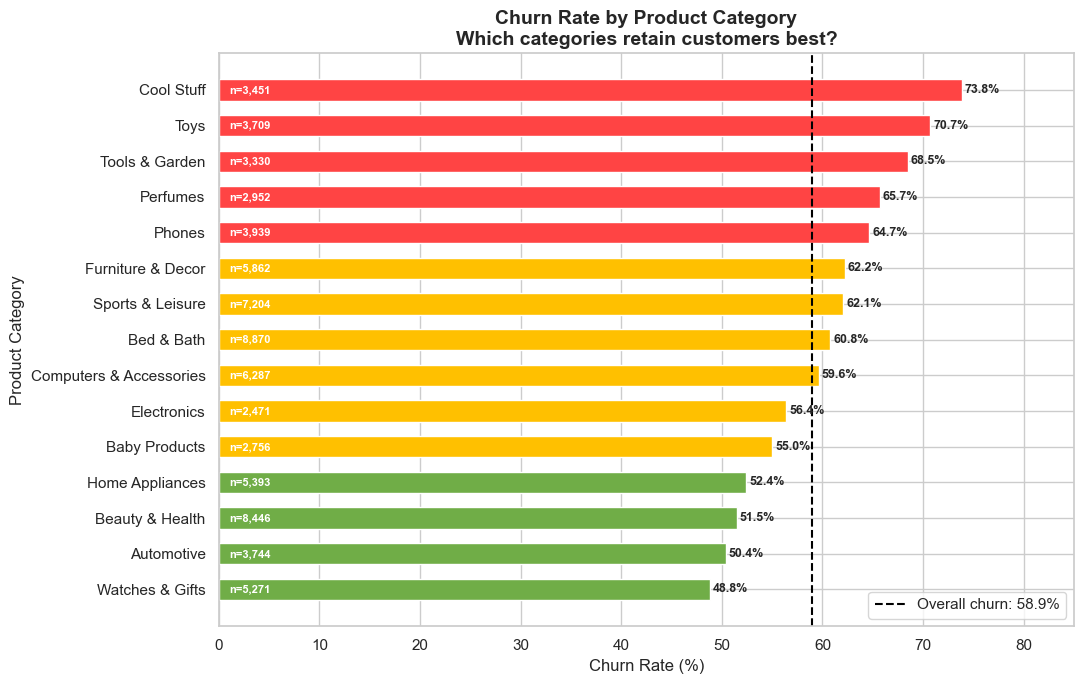

Chart 3 saved!


In [13]:
# --- Step 6: Plot horizontal bar chart ---

fig, ax = plt.subplots(figsize=(11, 7))

# Color each bar based on churn rate
# Green = low churn (good), Red = high churn (bad)
colors = []
for rate in churn_by_cat["churn_rate"]:
    if rate < 55:
        colors.append("#70ad47")   # green - good retention
    elif rate < 63:
        colors.append("#ffc000")   # amber - average
    else:
        colors.append("#ff4444")   # red - high churn

# Horizontal bar chart — easier to read long category names
bars = ax.barh(
    churn_by_cat["category_en"],    # y-axis: category names
    churn_by_cat["churn_rate"],     # x-axis: churn rate %
    color=colors,
    edgecolor="white",
    height=0.6
)

# --- Add % label at the end of each bar ---
for bar in bars:
    width = bar.get_width()    # for horizontal bars, width = the value
    ax.text(
        width + 0.3,           # just to the right of the bar end
        bar.get_y() + bar.get_height() / 2,   # vertically centered
        f"{width:.1f}%",
        ha="left", va="center",
        fontsize=9, fontweight="bold"
    )

# --- Add customer count inside each bar ---
for bar, count in zip(bars, churn_by_cat["customer_count"]):
    ax.text(
        1,                      # 1% from the left edge
        bar.get_y() + bar.get_height() / 2,
        f"n={count:,}",
        ha="left", va="center",
        fontsize=8, color="white",
        fontweight="bold"
    )

# --- Reference line ---
overall_churn = df["churned"].mean() * 100
ax.axvline(overall_churn, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall churn: {overall_churn:.1f}%")

# --- Formatting ---
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Product Category")
ax.set_title("Churn Rate by Product Category\nWhich categories retain customers best?")
ax.set_xlim(0, 85)
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart3_churn_by_category.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved!")

In [14]:
# ============================================================
# Chart 4: Churn Rate by Customer State
# Business Question: Does location affect customer loyalty?
# ============================================================

# --- Step 1: See all states and their customer counts ---
state_counts = df["customer_state"].value_counts()

print(f"Total unique states: {len(state_counts)}")
print("\nCustomers per state:")
print(state_counts)

Total unique states: 27

Customers per state:
customer_state
SP    39143
RJ    11913
MG    10996
RS     5166
PR     4768
SC     3444
BA     3158
DF     2017
ES     1928
GO     1894
PE     1546
CE     1257
PA      922
MT      855
MA      699
MS      680
PB      503
PI      464
RN      464
AL      387
SE      327
TO      267
RO      230
AM      140
AC       76
AP       66
RR       40
Name: count, dtype: int64


In [15]:
# ============================================================
# Chart 4: Churn Rate by State
# ============================================================

# --- Full state name mapping ---
state_names = {
    "SP": "São Paulo", "RJ": "Rio de Janeiro", "MG": "Minas Gerais",
    "RS": "Rio Grande do Sul", "PR": "Paraná", "SC": "Santa Catarina",
    "BA": "Bahia", "DF": "Distrito Federal", "ES": "Espírito Santo",
    "GO": "Goiás", "PE": "Pernambuco", "CE": "Ceará",
    "PA": "Pará", "MT": "Mato Grosso", "MA": "Maranhão",
    "MS": "Mato Grosso do Sul", "PB": "Paraíba", "PI": "Piauí",
    "RN": "Rio Grande do Norte", "AL": "Alagoas", "SE": "Sergipe",
    "TO": "Tocantins", "RO": "Rondônia", "AM": "Amazonas",
    "AC": "Acre", "AP": "Amapá", "RR": "Roraima"
}

# --- Calculate churn rate per state ---
churn_by_state = (
    df.groupby("customer_state")
    .agg(
        churn_rate=("churned", "mean"),
        customer_count=("churned", "count")
    )
    .reset_index()
)
churn_by_state["churn_rate"] = churn_by_state["churn_rate"] * 100

# --- Add full state names ---
churn_by_state["state_name"] = churn_by_state["customer_state"].map(state_names)

# --- Sort by churn rate ascending (best at bottom, worst at top) ---
churn_by_state = churn_by_state.sort_values("churn_rate", ascending=True)

# --- Flag small states (under 500 customers) as unreliable ---
churn_by_state["reliable"] = churn_by_state["customer_count"] >= 500

print(churn_by_state[["state_name", "churn_rate", "customer_count", "reliable"]].to_string(index=False))

         state_name  churn_rate  customer_count  reliable
          São Paulo   55.667680           39143      True
   Distrito Federal   56.916212            2017      True
             Paraná   58.850671            4768      True
 Mato Grosso do Sul   59.411765             680      True
         Pernambuco   59.896507            1546      True
          Tocantins   59.925094             267     False
              Bahia   59.974668            3158      True
            Roraima   60.000000              40     False
       Minas Gerais   60.412877           10996      True
              Amapá   60.606061              66     False
            Paraíba   60.834990             503      True
     Espírito Santo   61.462656            1928      True
              Goiás   61.615628            1894      True
  Rio Grande do Sul   61.962834            5166      True
     Rio de Janeiro   62.192563           11913      True
              Piauí   62.284483             464     False
Rio Grande do 

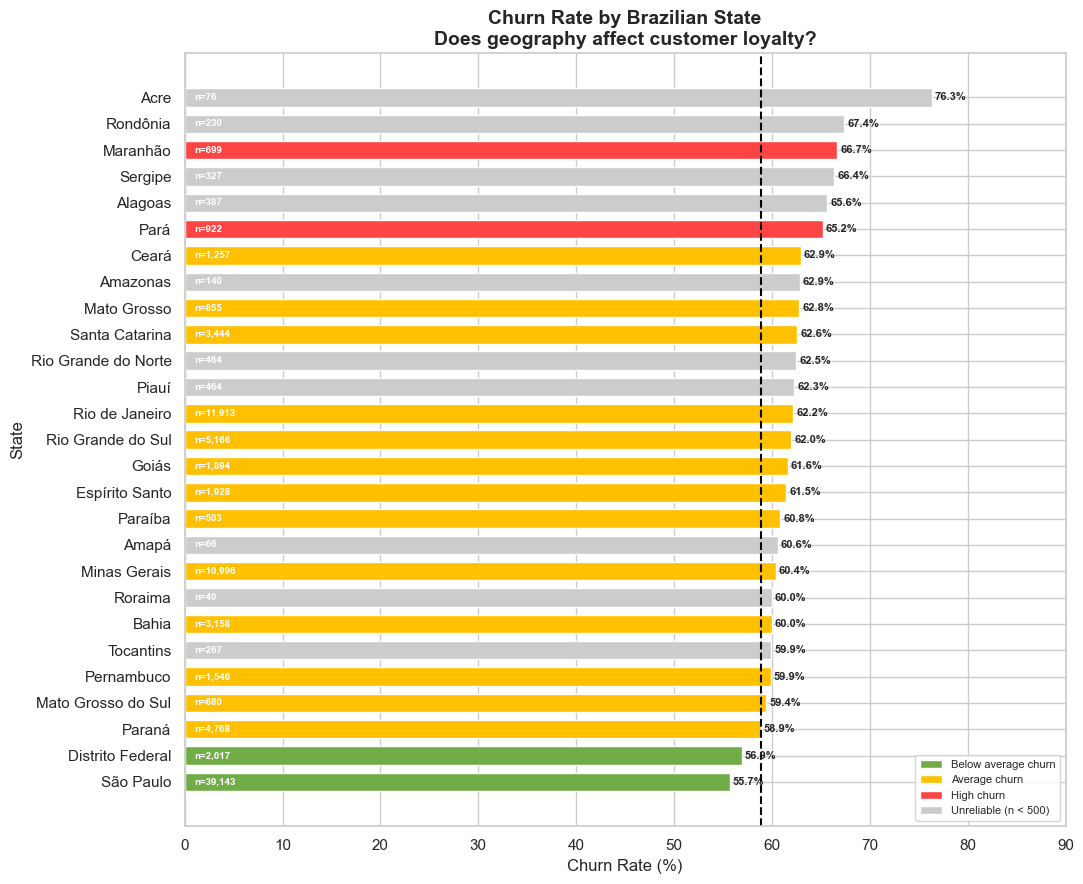

Chart 4 saved!


In [16]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 9))

# --- Color: reliable states solid, unreliable states faded ---
colors = []
for _, row in churn_by_state.iterrows():
    if not row["reliable"]:
        colors.append("#cccccc")        # grey = unreliable (small sample)
    elif row["churn_rate"] < 58:
        colors.append("#70ad47")        # green = below average churn
    elif row["churn_rate"] < 63:
        colors.append("#ffc000")        # amber = average
    else:
        colors.append("#ff4444")        # red = high churn

bars = ax.barh(
    churn_by_state["state_name"],
    churn_by_state["churn_rate"],
    color=colors,
    edgecolor="white",
    height=0.7
)

# --- Add churn % label at end of each bar ---
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        ha="left", va="center",
        fontsize=8, fontweight="bold"
    )

# --- Add customer count inside bar ---
for bar, count in zip(bars, churn_by_state["customer_count"]):
    ax.text(
        1,
        bar.get_y() + bar.get_height() / 2,
        f"n={count:,}",
        ha="left", va="center",
        fontsize=7, color="white",
        fontweight="bold"
    )

# --- Reference line ---
overall_churn = df["churned"].mean() * 100
ax.axvline(overall_churn, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall churn: {overall_churn:.1f}%")

# --- Legend explaining grey bars ---
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#70ad47", label="Below average churn"),
    Patch(facecolor="#ffc000", label="Average churn"),
    Patch(facecolor="#ff4444", label="High churn"),
    Patch(facecolor="#cccccc", label="Unreliable (n < 500)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

# --- Formatting ---
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("State")
ax.set_title("Churn Rate by Brazilian State\nDoes geography affect customer loyalty?")
ax.set_xlim(0, 90)

plt.tight_layout()
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart4_churn_by_state.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 4 saved!")

In [17]:
# ============================================================
# Chart 5: Total Spend vs Churn
# Business Question: Do high-value customers stay longer?
# ============================================================

# --- Step 1: Understand the spend distribution ---
print("Total spend stats:")
print(df["total_spend"].describe())

print("\nAvg spend per order stats:")
print(df["avg_spend_per_order"].describe())

print("\nSpend breakdown by churn:")
print(df.groupby("churned")[["total_spend", "avg_spend_per_order"]].mean().round(2))

Total spend stats:
count    93350.000000
mean       142.245178
std        216.939307
min          0.850000
25%         47.800000
50%         89.900000
75%        155.000000
max      13440.000000
Name: total_spend, dtype: float64

Avg spend per order stats:
count    93350.000000
mean       137.512409
std        209.876809
min          0.850000
25%         46.000000
50%         86.990000
75%        149.900000
max      13440.000000
Name: avg_spend_per_order, dtype: float64

Spend breakdown by churn:
         total_spend  avg_spend_per_order
churned                                  
0             144.74               139.77
1             140.51               135.94


In [18]:
# --- Step 2: Create spend buckets ---
# We use pd.cut() which splits a numeric column into bins automatically
# Based on describe() output: 25%=47, 50%=89, 75%=155, max=13440
# We'll create 5 meaningful business tiers

spend_bins   = [0, 50, 100, 200, 500, 15000]
spend_labels = ["<R$50", "R$50-100", "R$100-200", "R$200-500", "R$500+"]

df["spend_bucket"] = pd.cut(
    df["total_spend"],
    bins=spend_bins,
    labels=spend_labels,
    right=True    # intervals are (left, right] meaning left exclusive, right inclusive
)

# --- Step 3: Calculate churn rate and customer count per bucket ---
churn_by_spend = (
    df.groupby("spend_bucket", observed=True)
    .agg(
        churn_rate=("churned", "mean"),
        customer_count=("churned", "count")
    )
    .reset_index()
)
churn_by_spend["churn_rate"] = churn_by_spend["churn_rate"] * 100

print(churn_by_spend.to_string(index=False))

spend_bucket  churn_rate  customer_count
       <R$50   59.609037           27266
    R$50-100   60.445173           26237
   R$100-200   56.592120           24772
   R$200-500   59.398826           11411
      R$500+   57.177948            3664


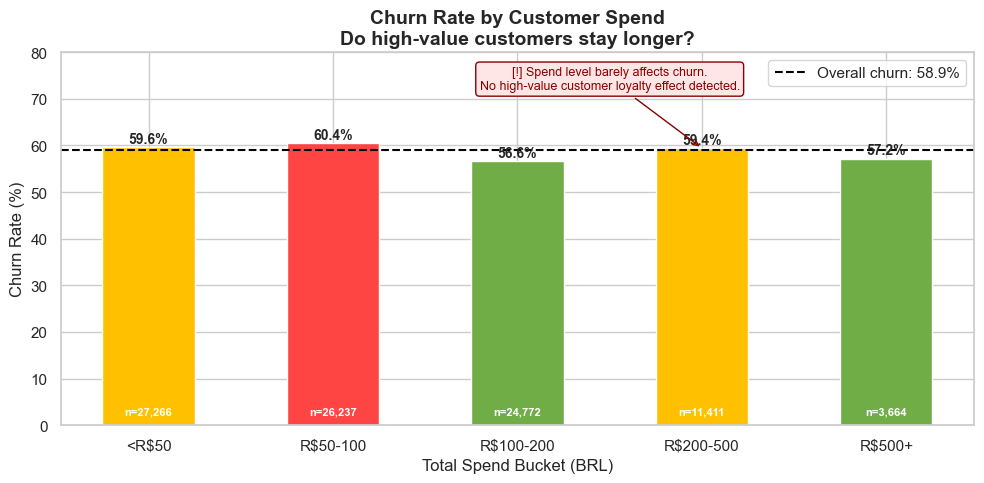

Chart 5 saved!


In [20]:
# --- Step 4: Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

colors = []
for rate in churn_by_spend["churn_rate"]:
    if rate < 58:
        colors.append("#70ad47")   # green
    elif rate < 60:
        colors.append("#ffc000")   # amber
    else:
        colors.append("#ff4444")   # red

bars = ax.bar(
    churn_by_spend["spend_bucket"].astype(str),   # x-axis: spend buckets
    churn_by_spend["churn_rate"],                  # y-axis: churn %
    color=colors,
    edgecolor="white",
    width=0.5
)

# --- Add % on top of each bar ---
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.3,
        f"{height:.1f}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

# --- Add customer count inside each bar ---
for bar, count in zip(bars, churn_by_spend["customer_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        2,
        f"n={count:,}",
        ha="center", va="bottom",
        fontsize=8, color="white",
        fontweight="bold"
    )

# --- Reference line ---
overall_churn = df["churned"].mean() * 100
ax.axhline(overall_churn, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall churn: {overall_churn:.1f}%")

# --- Annotation explaining the flat pattern ---
ax.annotate(
    "[!] Spend level barely affects churn.\nNo high-value customer loyalty effect detected.",
    xy=(3, 59.4),               # arrow points here (x=bucket index, y=churn rate)
    xytext=(2.5, 72),           # text appears here
    fontsize=9,
    color="darkred",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="darkred"),
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#ffe6e6", edgecolor="darkred")
)

# --- Formatting ---
ax.set_xlabel("Total Spend Bucket (BRL)")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Customer Spend\nDo high-value customers stay longer?")
ax.set_ylim(0, 80)
ax.legend()

plt.tight_layout()
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart5_churn_by_spend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved!")

In [21]:
# ============================================================
# Chart 6: Distribution of Total Orders per Customer
# Business Question: Is Olist fundamentally a one-purchase platform?
# ============================================================

# --- Step 1: Understand order frequency ---
print("Orders per customer stats:")
print(df["total_orders"].describe())

print("\nOrder frequency breakdown:")
order_counts = df["total_orders"].value_counts().sort_index()
print(order_counts.head(10))

print(f"\nCustomers with exactly 1 order: {(df['total_orders'] == 1).sum():,}")
print(f"That's: {(df['total_orders'] == 1).mean()*100:.1f}% of all customers")
print(f"\nCustomers with 2+ orders: {(df['total_orders'] >= 2).sum():,}")
print(f"That's: {(df['total_orders'] >= 2).mean()*100:.1f}% of all customers")

Orders per customer stats:
count    93350.000000
mean         1.039089
std          0.249787
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: total_orders, dtype: float64

Order frequency breakdown:
total_orders
1     90459
2      2367
3       366
4       117
5        23
6        11
7         5
9         1
15        1
Name: count, dtype: int64

Customers with exactly 1 order: 90,459
That's: 96.9% of all customers

Customers with 2+ orders: 2,891
That's: 3.1% of all customers


In [22]:
# ============================================================
# Chart 6: Orders Distribution
# ============================================================

# --- Step 2: Prepare data ---
# Cap at 5+ orders to avoid a long empty tail
# Anyone with 5 or more orders gets grouped together
df["orders_capped"] = df["total_orders"].clip(upper=5)
# clip(upper=5) replaces any value above 5 with 5
# So 6,7,8...15 all become 5 — we'll label this bar "5+"

order_dist = df["orders_capped"].value_counts().sort_index().reset_index()
order_dist.columns = ["orders", "customer_count"]

# Replace the "5" label with "5+" for clarity
order_dist["orders_label"] = order_dist["orders"].astype(str)
order_dist.loc[order_dist["orders"] == 5, "orders_label"] = "5+"

# Calculate percentage of total customers
order_dist["pct"] = order_dist["customer_count"] / len(df) * 100

print(order_dist)

   orders  customer_count orders_label        pct
0       1           90459            1  96.903053
1       2            2367            2   2.535619
2       3             366            3   0.392073
3       4             117            4   0.125335
4       5              41           5+   0.043921


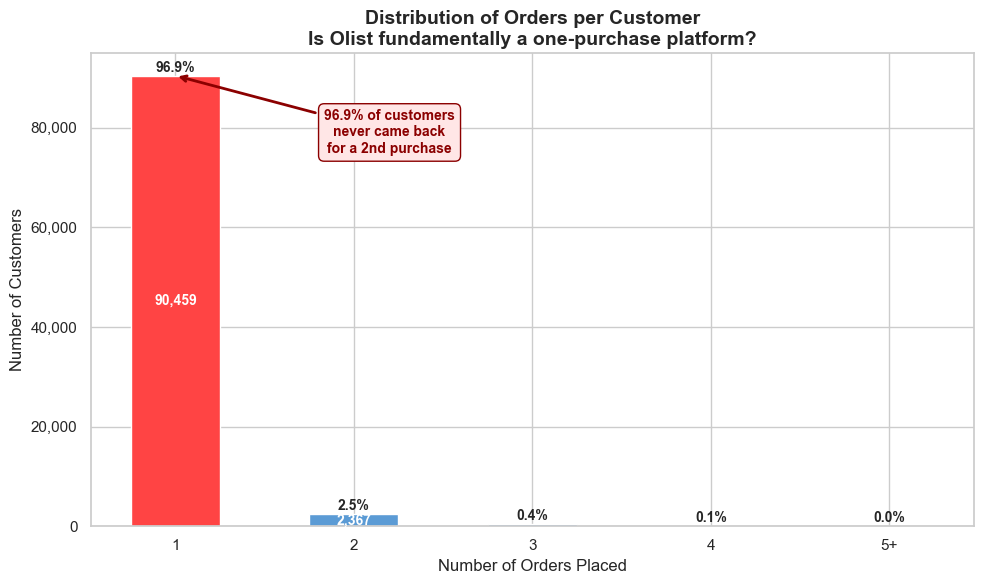

Chart 6 saved!


In [23]:
# --- Step 3: Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

# Special colors: first bar (1 order) bright red to highlight the problem
# Rest are steel blue — they're the "good" repeat customers
colors = ["#ff4444"] + ["#5b9bd5"] * (len(order_dist) - 1)

bars = ax.bar(
    order_dist["orders_label"],
    order_dist["customer_count"],
    color=colors,
    edgecolor="white",
    width=0.5
)

# --- Add % label on top of each bar ---
for bar, pct in zip(bars, order_dist["pct"]):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 200,                    # 200 customers above bar top
        f"{pct:.1f}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

# --- Add raw count inside each bar ---
for bar, count in zip(bars, order_dist["customer_count"]):
    height = bar.get_height()
    if height > 2000:                    # only add text if bar is tall enough
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,                  # vertically centered in bar
            f"{count:,}",
            ha="center", va="center",
            fontsize=10, color="white",
            fontweight="bold"
        )

# --- Annotate the red bar with the key insight ---
ax.annotate(
    "96.9% of customers\nnever came back\nfor a 2nd purchase",
    xy=(0, 90459),                       # arrow tip: top of first bar
    xytext=(1.2, 75000),                 # text position
    fontsize=10,
    color="darkred",
    fontweight="bold",
    ha="center",
    arrowprops=dict(arrowstyle="->", color="darkred", lw=2),
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ffe6e6", edgecolor="darkred")
)

# --- Formatting ---
ax.set_xlabel("Number of Orders Placed")
ax.set_ylabel("Number of Customers")
ax.set_title("Distribution of Orders per Customer\nIs Olist fundamentally a one-purchase platform?")

# Format y-axis with comma separators (50000 -> 50,000)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.tight_layout()
plt.savefig(r"C:\Users\vedik\OneDrive\Desktop\Olist Churn Project\outputs\chart6_orders_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart 6 saved!")

**Olist's 58.9% churn rate is driven not by poor satisfaction, but by structural platform behaviour — 96.9% of customers place just one order and never return. Churn worsens significantly with delivery delays (+24 points for very late deliveries) and varies by geography, with northern states churning most due to logistics gaps. High-value customers receive no loyalty incentive to return. The platform's biggest opportunity lies not in acquisition but in converting one-time buyers into repeat customers through loyalty programs, logistics investment, and category-specific retention strategies.**